<a href="https://colab.research.google.com/github/faiq191/244107020214-machine-learning/blob/main/JS05/JS05_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LAB ASSIGNMENT 1: KNN on Voice Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

1. Load Dataset

In [ ]:
# 1. Load Dataset
voice_df = pd.read_csv('voice.csv')

In [ ]:
# Encode Target Variable ('label': 'male' -> 1, 'female' -> 0)
le = LabelEncoder()
voice_df['label'] = le.fit_transform(voice_df['label'])

X = voice_df.drop('label', axis=1)
y = voice_df['label']

In [ ]:
# Standardize Features (Crucial for KNN)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

2. Feature Selection Experiment

In [14]:
# Evaluate Model Performance Across Top K Features
feature_results = {}
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

for k_feat in range(1, len(X.columns) + 1):
    selector = SelectKBest(score_func=f_classif, k=k_feat)
    X_train_sel = selector.fit_transform(X_train_full, y_train)
    X_test_sel = selector.transform(X_test_full)

    knn_temp = KNeighborsClassifier(n_neighbors=5)
    knn_temp.fit(X_train_sel, y_train)
    acc = accuracy_score(y_test, knn_temp.predict(X_test_sel))

    selected_cols = X.columns[selector.get_support()].tolist()
    feature_results[k_feat] = {'accuracy': acc, 'features': selected_cols}

In [15]:
# Find Optimal Feature Subset
best_num_features = max(feature_results, key=lambda k: feature_results[k]['accuracy'])
best_features = feature_results[best_num_features]['features']

print(f"--- Feature Selection Results ---")
print(f"Optimal Number of Features: {best_num_features}")
print(f"Selected Best Features:\n{best_features}\n")

--- Feature Selection Results ---
Optimal Number of Features: 6
Selected Best Features:
['sd', 'Q25', 'IQR', 'sp.ent', 'sfm', 'meanfun']



In [16]:
# Prepare Data with Best Features
X_opt = X_scaled[best_features]
X_train, X_test, y_train, y_test = train_test_split(X_opt, y, test_size=0.2, random_state=42, stratify=y)

3. Tuning k (Neighbors) & Analytical Plot

In [19]:
k_range = range(1, 31)
cv_scores = []
train_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)

    # 5-Fold Cross Validation (harus menjorok ke dalam / ada indentasi 4 spasi)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

    # Training Accuracy (untuk cek overfitting)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))

best_k = k_range[np.argmax(cv_scores)]

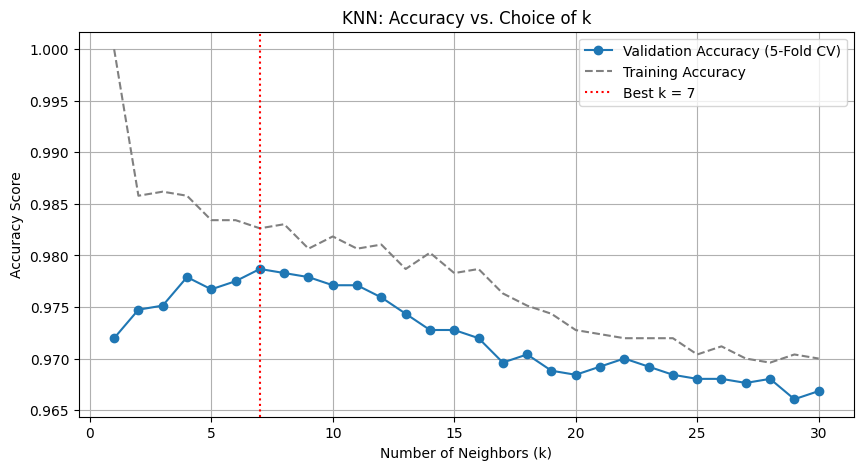

In [20]:
# Plot k vs Accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, marker='o', label='Validation Accuracy (5-Fold CV)')
plt.plot(k_range, train_scores, linestyle='--', color='gray', label='Training Accuracy')
plt.axvline(best_k, color='red', linestyle=':', label=f'Best k = {best_k}')
plt.title('KNN: Accuracy vs. Choice of k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy Score')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# Final Evaluation on Test Set with Optimal k
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)
y_pred_knn = final_knn.predict(X_test)

print(f"--- Lab 1 Final Model Evaluation (k = {best_k}) ---")
print(f"Test Set Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

--- Lab 1 Final Model Evaluation (k = 7) ---
Test Set Accuracy: 0.9811

              precision    recall  f1-score   support

      female       0.98      0.98      0.98       317
        male       0.98      0.98      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634

